<a href="https://colab.research.google.com/github/K1taK1ta/deep-learning-notebooks/blob/main/image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import transformers
import tensorflow as tf
import tqdm.notebook as tqdm
import sklearn.model_selection
import matplotlib.pyplot as plt
import datetime
import tables
import PIL.Image
import torch
import keras

from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader
from google.colab import drive
from pathlib import Path



In [ ]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except:
        pass

In [ ]:
drive.mount('/content/drive/')
save_folder = '/content/drive/MyDrive/Colab Notebooks/Other_ML/'

Mounted at /content/drive/


# Data

Load and prepare your dataset. Dataset should have at least 10k samples in it. Each dataset cannot be used by more than two students.

#### Zip

In [ ]:
import zipfile

zip_path = os.path.join(save_folder, "archive.zip")

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(save_folder)

print("Файлы после распаковки:", os.listdir(save_folder))


Файлы после распаковки: ['Transfer_Cross-entropy.ipynb', 'archive.zip', 'image_classification.ipynb', 'seg_pred', 'seg_test', 'seg_train']


In [ ]:
print("Файлы после распаковки:", os.listdir(save_folder))


Файлы после распаковки: ['Transfer_Cross-entropy.ipynb', 'archive.zip', 'seg_pred', 'seg_test', 'seg_train', 'embeddings_train.hdf5', 'embeddings_test.hdf5', 'best_model.keras', 'image_classification.ipynb']


In [ ]:
for root, dirs, files in os.walk(save_folder):
    print(root, len(files), "files")


/content/drive/MyDrive/Colab Notebooks/Other_ML/ 6 files
/content/drive/MyDrive/Colab Notebooks/Other_ML/seg_pred 0 files
/content/drive/MyDrive/Colab Notebooks/Other_ML/seg_pred/seg_pred 7301 files
/content/drive/MyDrive/Colab Notebooks/Other_ML/seg_test 0 files
/content/drive/MyDrive/Colab Notebooks/Other_ML/seg_test/seg_test 0 files
/content/drive/MyDrive/Colab Notebooks/Other_ML/seg_test/seg_test/buildings 437 files
/content/drive/MyDrive/Colab Notebooks/Other_ML/seg_test/seg_test/forest 474 files
/content/drive/MyDrive/Colab Notebooks/Other_ML/seg_test/seg_test/glacier 553 files
/content/drive/MyDrive/Colab Notebooks/Other_ML/seg_test/seg_test/mountain 525 files
/content/drive/MyDrive/Colab Notebooks/Other_ML/seg_test/seg_test/sea 510 files
/content/drive/MyDrive/Colab Notebooks/Other_ML/seg_test/seg_test/street 501 files
/content/drive/MyDrive/Colab Notebooks/Other_ML/seg_train 0 files
/content/drive/MyDrive/Colab Notebooks/Other_ML/seg_train/seg_train 0 files
/content/drive/MyDr

In [ ]:
!ls -R "/content/drive/MyDrive/Colab Notebooks/Other_ML/"

'/content/drive/MyDrive/Colab Notebooks/Other_ML/':
archive.zip		    seg_pred  seg_train
image_classification.ipynb  seg_test  Transfer_Cross-entropy.ipynb

'/content/drive/MyDrive/Colab Notebooks/Other_ML/seg_pred':
seg_pred

'/content/drive/MyDrive/Colab Notebooks/Other_ML/seg_pred/seg_pred':
10004.jpg  13296.jpg  16412.jpg  19543.jpg  22613.jpg  3947.jpg  6943.jpg
10005.jpg  13297.jpg  16415.jpg  19549.jpg  22615.jpg  3953.jpg  6948.jpg
10012.jpg  13299.jpg  16424.jpg  19557.jpg  22618.jpg  3962.jpg  6950.jpg
10013.jpg  132.jpg    16428.jpg  19558.jpg  22621.jpg  3966.jpg  6951.jpg
10017.jpg  13302.jpg  16429.jpg  19560.jpg  22622.jpg  3970.jpg  6952.jpg
10021.jpg  13303.jpg  16436.jpg  19561.jpg  22627.jpg  3975.jpg  6957.jpg
10034.jpg  13305.jpg  16442.jpg  19562.jpg  22630.jpg  3976.jpg  695.jpg
10038.jpg  1330.jpg   16444.jpg  19564.jpg  22638.jpg  3979.jpg  6964.jpg
1003.jpg   13316.jpg  16445.jpg  19568.jpg  22641.jpg  3981.jpg  6965.jpg
10040.jpg  13318.jpg  16446.jpg  19569.

#### Load

In [ ]:
path_train = save_folder  + 'seg_train/seg_train/'
path_test = save_folder  + 'seg_test/seg_test/'

In [ ]:
def load_image_paths(root):
  root = Path(root)
  items = []
  for class_name in (p.name for p in root.iterdir() if p.is_dir()):
      class_dir = root / class_name
      for img_path in class_dir.glob("*.jpg"):
        items.append((str(img_path), class_name))

  df = pd.DataFrame(items, columns=["filepaths", "labels"])
  df['labels'], uniques = pd.factorize(df['labels'])
  return df, uniques


df_train_paths, map = load_image_paths(path_train)
df_test_paths, map = load_image_paths(path_test)

print(df_train_paths.shape)
print(df_test_paths.shape)
print(map)

(14034, 2)
(3000, 2)
Index(['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'], dtype='object')


# Backbone

Load pretrained model from Hugging Face (or some other model repository if it's more convenient). Model should be trained on Feature Extraction task.

In [ ]:
backbone = transformers.AutoModel.from_pretrained("google/vit-base-patch16-224-in21k")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
backbone = backbone.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [ ]:
x = torch.randn(1, 3, 224, 224).to(device)

with torch.no_grad():
    outputs = backbone(pixel_values=x)

print("Форма last_hidden_state:", outputs.last_hidden_state.shape)

Форма last_hidden_state: torch.Size([1, 197, 768])


Load tokenizer to be used with the model

---



In [ ]:
processor = transformers.AutoImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


# Feature extraction

Since we will not be training the backbone, extract features from your dataset.

Run the backbone on the images and save the extracted features. Don't forget to process the images. Images don't have to be of the same size, though it would be faster if they were. If the images don't fit in memory, lazily load them from disk

In [ ]:
embedding_dim = 768
filters = tables.Filters(3, "blosc:lz4")
BATCH_SIZE = 64

def prepare_embeddings(data, n_samples, name_file):
  with tables.open_file(name_file, "w") as file, torch.no_grad():
    array = file.create_carray(file.root, "embeddings", tables.Float32Atom(), shape=(n_samples, embedding_dim), filters=filters)
    labels = file.create_carray(file.root, "labels", tables.Int8Atom(), shape=(n_samples,), filters=filters)

    for i in tqdm.trange(0, n_samples, BATCH_SIZE, desc="Encoding batches"):
      image_paths = data['filepaths'].iloc[i:i + BATCH_SIZE]
      images = [PIL.Image.open(path).convert('RGB') for path in image_paths]
      images = processor(images, return_tensors='pt').to(backbone.device)
      features = backbone(**images).pooler_output.cpu().numpy()
      array[i:i + BATCH_SIZE] = features
      labels[i:i + BATCH_SIZE] = data['labels'].iloc[i:i + BATCH_SIZE].to_numpy()




In [ ]:
hdf_path_train = os.path.join(save_folder, "embeddings_train.hdf5")
prepare_embeddings(df_train_paths, len(df_train_paths), hdf_path_train)

Encoding batches:   0%|          | 0/220 [00:00<?, ?it/s]

In [ ]:
import os

if os.path.exists(hdf_path_train):
    print("Файл найден по пути:", hdf_path_train)
else:
    print("Файл не найден!")


Файл найден по пути: /content/drive/MyDrive/Colab Notebooks/Other_ML/embeddings_train.hdf5


In [ ]:
hdf_path_test = os.path.join(save_folder, "embeddings_test.hdf5")
prepare_embeddings(df_test_paths, len(df_test_paths), hdf_path_test)


Encoding batches:   0%|          | 0/47 [00:00<?, ?it/s]

In [ ]:
import os

if os.path.exists(hdf_path_test):
    print("Файл найден по пути:", hdf_path_test)
else:
    print("Файл не найден!")


Файл найден по пути: /content/drive/MyDrive/Colab Notebooks/Other_ML/embeddings_test.hdf5


In [ ]:
hdf_path_test = os.path.join(save_folder, "embeddings_test.hdf5")
hdf_path_train = os.path.join(save_folder, "embeddings_train.hdf5")


In [ ]:
from google.colab import files

files.download(hdf_path_test)
files.download(hdf_path_train)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def read_hd(name="embeddings_train.hdf5"):
  with tables.open_file(name, "r") as file:
      X = file.root.embeddings[:]
      y = file.root.labels[:]

      print("X shape:", X.shape)
      print("y shape:", y.shape)
      return X, y


# Prepare train/test data

Split your data (extracted features and labels) into train and test subsets.

In [ ]:
X_train, y_train = read_hd(hdf_path_train)
X_test, y_test = read_hd(hdf_path_test)

X shape: (14034, 768)
y shape: (14034,)
X shape: (3000, 768)
y shape: (3000,)


Prepare `tf.data.Dataset` or some other way for the data to be used during training.

In [ ]:
train_X = tf.data.Dataset.from_tensor_slices(X_train)
train_y = tf.data.Dataset.from_tensor_slices(y_train)
train_dataset = tf.data.Dataset.zip((train_X, train_y)).batch(128)

test_X = tf.data.Dataset.from_tensor_slices(X_test)
test_y = tf.data.Dataset.from_tensor_slices(y_test)
test_dataset = tf.data.Dataset.zip((test_X, test_y)).batch(128)

# Build the model

Build a simple model. The model should accept an extracted feature vector and return a vector of class logits (or probabilities). Model should only have a couple (or even 1) layers with weights.

In [ ]:
input_dim = X_train.shape[1]
num_classes = len(np.unique(y_train))

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim,)),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])


Compile the model. Choose loss and metrics.

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
def get_callbacks(filepath):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=filepath,
            save_best_only=True,
            monitor='val_loss',
            mode='min',
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-5,
            mode='min',
            verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True,
            mode='min',
            verbose=1
        )
    ]


# Train the model

In [ ]:
filepath_best = save_folder + '/best_model.keras'
callbacks = get_callbacks(filepath_best)

model.fit(
    train_dataset,
    epochs=40,
    validation_data=test_dataset,
    callbacks=callbacks,
)


Epoch 1/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6491 - loss: 2.4660
Epoch 1: val_loss improved from inf to 2.79272, saving model to /content/drive/MyDrive/Colab Notebooks/Other_ML//best_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.6478 - loss: 2.4677 - val_accuracy: 0.1670 - val_loss: 2.7927 - learning_rate: 0.0010
Epoch 2/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4587 - loss: 1.8136
Epoch 2: val_loss did not improve from 2.79272
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4601 - loss: 1.8096 - val_accuracy: 0.2703 - val_loss: 3.8754 - learning_rate: 0.0010
Epoch 3/40
 93/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6016 - loss: 1.8250
Epoch 3: val_loss did not improve from 2.79272

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6225 - loss: 1.6989 - val_accuracy: 0.3393 - val_loss: 3.3976 - learning_rate: 0.0010
Epoch 4/40
109/1

# Evaluation

Evalute the model on test data.

In [ ]:
loss, accuracy = model.evaluate(test_dataset)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9245 - loss: 0.2056


Plot confusion matrix.

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


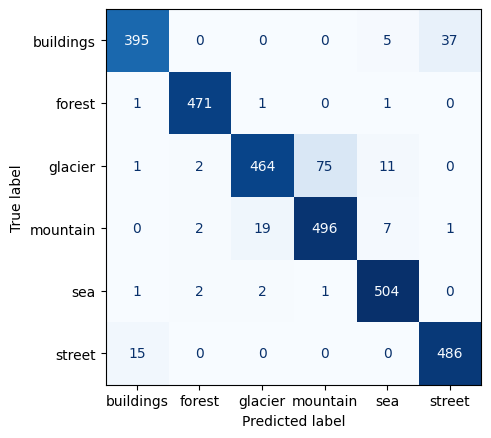

In [ ]:
import matplotlib.pyplot as plt
import sklearn.metrics

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

_, ax = plt.subplots(figsize=(5, 5))

sklearn.metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    ax=ax,
    display_labels=map,
    colorbar=False,
    cmap='Blues',
    values_format='d'
)


plt.tight_layout()
plt.show()

Perform dimensiality reduction and plot the extracted features. Do classes form clusters?

(PCA) — это метод линейного уменьшения размерности, который:

Находит направления (компоненты), вдоль которых данные имеют максимальную дисперсию.

Проецирует данные на эти направления, уменьшая число признаков, сохраняя как можно больше информации.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def scale(data): # C пар классическая формула mix-man
    return np.array([
        (i - data.min()) / (data.max() - data.min())
        for i in data
    ])


print(X_train.shape) # [num_images, 768]
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scale(X_train))



(14034, 768)


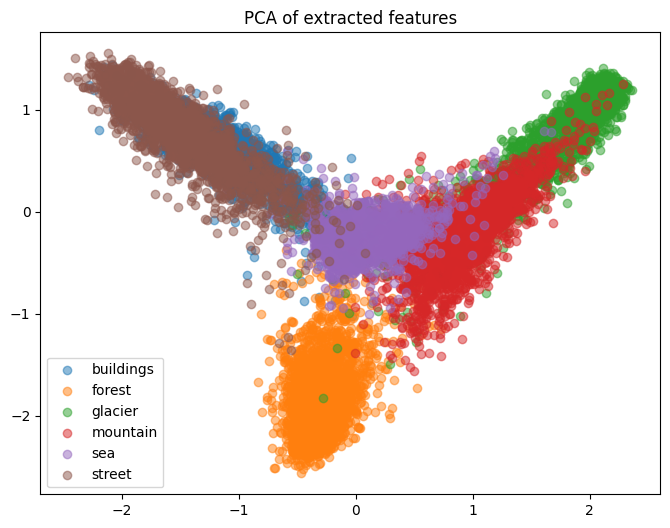

In [ ]:
plt.figure(figsize=(8,6))
for label in np.unique(y_train):
    plt.scatter(X_pca[y_train==label, 0],
                X_pca[y_train==label, 1],
                label=map[label], alpha=0.5)
plt.legend()
plt.title("PCA of extracted features")
plt.show()


t-SNE (t-distributed Stochastic Neighbor Embedding) — это метод непрямого (нелинейного) уменьшения размерности, который:

Берёт данные в высокоразмерном пространстве (например, 768D эмбеддинги).

Ставит цель: сохранять локальную структуру — то есть близкие объекты в исходном пространстве остаются близкими в низкоразмерном (2D или 3D).

Проецирует данные в 2D или 3D для визуализации.

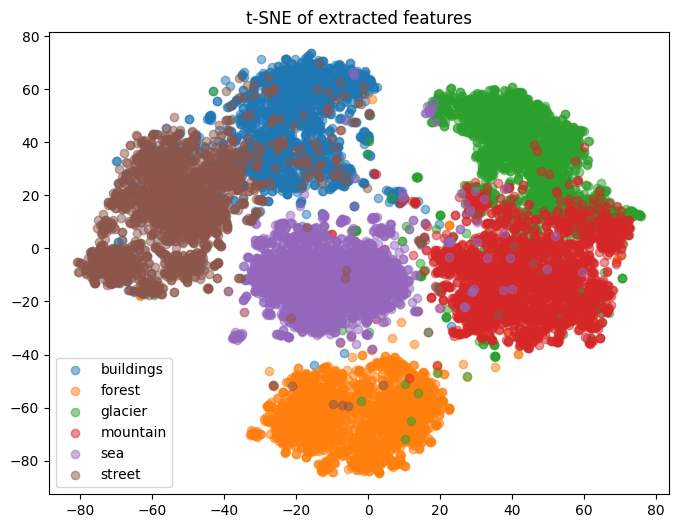

In [ ]:
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(scale(X_train))

plt.figure(figsize=(8,6))
y_train_np = np.array(y_train)
for label in np.unique(y_train_np):
    plt.scatter(X_tsne[y_train_np==label, 0],
                X_tsne[y_train_np==label, 1],
                label=map[label], alpha=0.5)
plt.legend()
plt.title("t-SNE of extracted features")
plt.show()


# Bonus

Check if the feature extractor model can be used without a classifier layer (how large is the average feature vector similarity inbetween same in different classes)

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict

# Создаёт словарь, где по умолчанию каждому ключу соответствует пустой список.
class_features = defaultdict(list)
for f, label in zip(X_test, y_test):
    class_features[label].append(f)

"""
class_features = {
    0: [f1, f2, f3, f9, ...],   # все эмбеддинги класса 0
    1: [f4, f8, f20, ...],      # все эмбеддинги класса 1
    2: [...],                   # эмбеддинги класса 2
    3: [...],                   # и так далее
}
Где:

len(class_features[k]) — количество примеров класса k

D — размер эмбеддинга, например 768
(предполагается, что каждый f имеет форму (D,))
"""

# Превращаем списки в массивы
for k in class_features:
    class_features[k] = np.stack(class_features[k])


"""

class_features = {
    "cat": np.array([...]),   # все коты
    "dog": np.array([...]),   # все собаки
    "car": np.array([...])    # все машины
}
"""



# Нормализуем признаки (для косинусной схожести)
for k in class_features:
    feats = class_features[k]
    feats = feats / np.linalg.norm(feats, axis=1, keepdims=True) # Делим каждый вектор на его длину → получаем вектор единичной длины.
    class_features[k] = feats

labels = list(class_features.keys())



In [ ]:
sim_matrix = pd.DataFrame(
    index=map,
    columns=map,
    dtype=float
)

same_class_sims = []

for label_i in labels:
    feats_i = class_features[label_i] # пример class_features[0].shape == (423, 768)
    sims = cosine_similarity(feats_i)


    '''
    И это будет таблица вида:

              Obj1   Obj2   Obj3
    Obj1       1    0.72   0.55
    Obj2     0.72     1    0.11
    Obj3     0.55   0.11     1
    '''


    sims_no_diag = sims[~np.eye(sims.shape[0],dtype=bool)] # Не берем диагональ # Результат становится плоским вектором
    same_class_sims.append(sims_no_diag.mean())

    for label_j in labels:
        feats_j = class_features[label_j] # пример class_features[0].shape == (423, 768)


        if label_i == label_j:
            sim_matrix.loc[map[label_i], map[label_j]] = np.nan # Если сравниваем класс с самим собой, то ставим в матрицу NaN.
        else:
            sim_matrix.loc[map[label_i], map[label_j]] = cosine_similarity(feats_i, feats_j).mean()



        """
        Это создаёт матрицу:

        shape = (N_i, N_j)


        Каждый элемент — косинусная похожесть:

        sim[i][j] = cos(f_i_object_i, f_j_object_j)
        """



        """
Пример (маленькая матрица 3×2):

[[0.9, 0.8],
 [0.85, 0.82],
 [0.7, 0.6]]
mean = (0.9 + 0.8 + 0.85 + 0.82 + 0.7 + 0.6) / 6
"""


In [ ]:
for i, sim in enumerate(same_class_sims):
    print(f"{map[i]} внутренняя схожесть: {sim}")

print("Средняя внутренняя схожесть всех классов:", np.mean(same_class_sims))

buildings внутренняя схожесть: 0.5188215374946594
forest внутренняя схожесть: 0.5274136662483215
glacier внутренняя схожесть: 0.7009334564208984
mountain внутренняя схожесть: 0.6046268939971924
sea внутренняя схожесть: 0.568855881690979
street внутренняя схожесть: 0.5489944815635681
Средняя внутренняя схожесть всех классов: 0.5782743


In [ ]:
sim_matrix["mean"] = sim_matrix.mean(axis=1, skipna=True)
print(f'Схожесть между классами по каждому классу, в разрезе и среднее')
print()
print(sim_matrix)
print()
print(f'Средняя схожесть между классами: {sim_matrix["mean"].mean()}')

Схожесть между классами по каждому классу, в разрезе и среднее

           buildings    forest   glacier  mountain       sea    street  \
buildings        NaN  0.374313  0.403273  0.408481  0.407203  0.472425   
forest      0.374313       NaN  0.389163  0.419320  0.385826  0.371946   
glacier     0.403273  0.389163       NaN  0.543895  0.449695  0.393443   
mountain    0.408481  0.419320  0.543895       NaN  0.455065  0.407706   
sea         0.407203  0.385826  0.449695  0.455065       NaN  0.400316   
street      0.472425  0.371946  0.393443  0.407706  0.400316       NaN   

               mean  
buildings  0.413139  
forest     0.388114  
glacier    0.435894  
mountain   0.446893  
sea        0.419621  
street     0.409167  

Средняя схожесть между классами: 0.41880472600460056


In [ ]:
sim_matrix_filled = sim_matrix.copy()
sim_matrix_filled = sim_matrix_filled.drop(columns=["mean"])
np.fill_diagonal(sim_matrix_filled.values, same_class_sims)

In [ ]:
# sim_matrix_filled.style.format("{:.3f}").background_gradient(cmap="viridis")

(
    sim_matrix_filled
    .style
    .format("{:.3f}")
    .background_gradient(cmap="viridis", axis=0)
    .set_properties(**{
        "font-size": "16pt",
        "padding": "12px",
        "text-align": "center"
    })
    .set_table_styles([
        {"selector": "th", "props": [
            ("font-size", "16pt"),
            ("padding", "14px")
        ]},
        {"selector": "caption", "props": [
            ("font-size", "18pt"),
            ("margin-bottom", "12px")
        ]}
    ])
)

,buildings,forest,glacier,mountain,sea,street
buildings,0.519,0.374,0.403,0.408,0.407,0.472
forest,0.374,0.527,0.389,0.419,0.386,0.372
glacier,0.403,0.389,0.701,0.544,0.450,0.393
mountain,0.408,0.419,0.544,0.605,0.455,0.408
sea,0.407,0.386,0.450,0.455,0.569,0.400
street,0.472,0.372,0.393,0.408,0.400,0.549


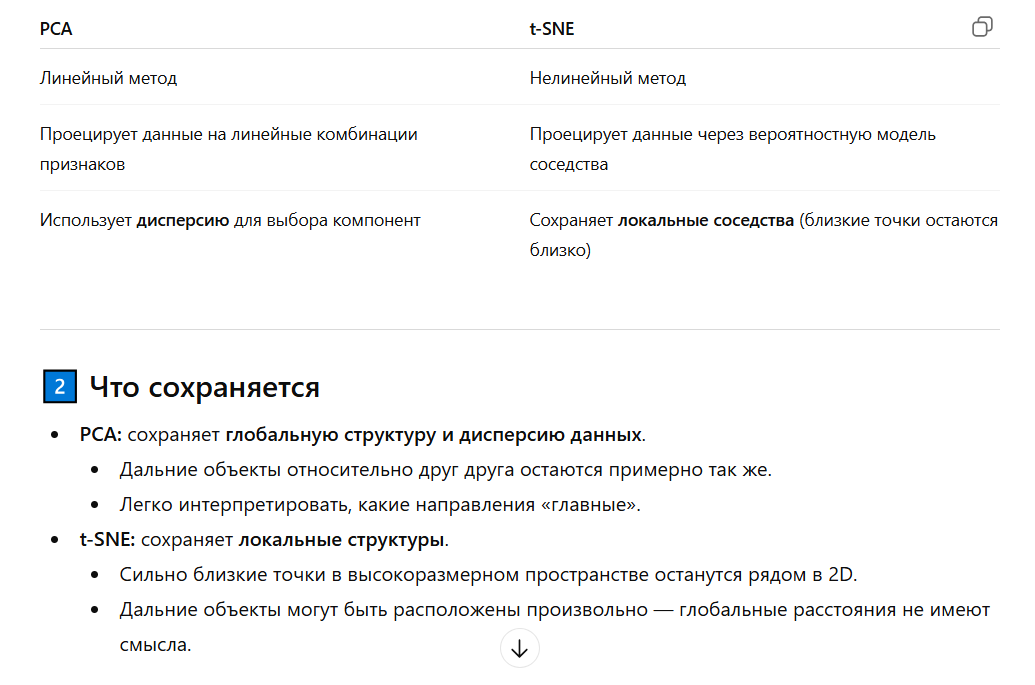

Почему важна нормализация:

PCA ищет направления с максимальной дисперсией.

Если признаки имеют разный масштаб, PCA будет отдавать предпочтение признакам с большим диапазоном, даже если они не информативны.